In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



In [2]:
def clip_outliers(df_in, cols, lower_q=0.01, upper_q=0.99):
    df_out = df_in.copy()
    for col in cols:
        if col in df_out.columns and df_out[col].notna().sum() > 0:
            lower = df_out[col].quantile(lower_q)
            upper = df_out[col].quantile(upper_q)
            df_out[col] = df_out[col].clip(lower=lower, upper=upper)
    return df_out

In [3]:
def label_cluster(row):
    if row["avg_crash"] > 0.25 or row["avg_injured"] > 0.20:
        return "Alto riesgo de seguridad"
    elif row["avg_fire"] > 0.08:
        return "Riesgo eléctrico o combustible"
    elif row["avg_risk"] < 0.15:
        return "Base confiable"
    elif row["avg_complaints"] > cluster_profile["avg_complaints"].median():
        return "Desgaste y volumen alto"
    else:
        return "Riesgo moderado"

In [4]:
def decision_label(score):
    if score < 0.14:
        return "Recomendado"
    elif score < 0.25:
        return "Con precaución"
    return "No recomendado"

In [5]:
def label_subcluster(row):
    if row["avg_crash"] > 0.15 or row["avg_injured"] > 0.10:
        return "Riesgo de seguridad moderado"
    elif row["avg_fire"] > 0.05:
        return "Riesgo eléctrico o combustible"
    elif row["avg_complaints"] > subcluster_profile["avg_complaints"].median():
        return "Alto volumen de quejas (desgaste)"
    elif row["avg_age"] > subcluster_profile["avg_age"].median():
        return "Vehículos con mayor antigüedad"
    else:
        return "Base confiable"

In [6]:
df = pd.read_csv("df_final.csv")

# estandarizar nombres de columnas
df.columns = [c.strip() for c in df.columns]

# eliminar columnas que no usarás por ahora
df = df.drop(columns=["LANG", "COMPDESC_len"], errors="ignore")

# normalizar texto clave
for col in ["MAKETXT", "MODELTXT", "COMPDESC", "CDESCR"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# convertir numéricas
num_cols = ["INJURED", "DEATHS", "MILES", "OCCURENCES", "YEARTXT", "AGE"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# binarios
df["FIRE"] = df["FIRE"].map({"Y": 1, "N": 0})
df["CRASH"] = df["CRASH"].map({"Y": 1, "N": 0})

# imputar OCCURENCES con 1
df["OCCURENCES"] = df["OCCURENCES"].fillna(1)

# negativos imposibles
df.loc[df["MILES"] < 0, "MILES"] = np.nan
df.loc[df["OCCURENCES"] < 0, "OCCURENCES"] = np.nan
df.loc[df["AGE"] < 0, "AGE"] = np.nan
df.loc[df["INJURED"] < 0, "INJURED"] = np.nan
df.loc[df["DEATHS"] < 0, "DEATHS"] = np.nan

# filtrar extremos absurdos en lesionados/muertes por registro
df = df[(df["INJURED"].fillna(0) <= 10)].copy()
df = df[(df["DEATHS"].fillna(0) <= 10)].copy()

print("Shape:", df.shape)
df.head()

Shape: (390357, 16)


,MAKETXT,MODELTXT,YEARTXT,CRASH,FAILDATE,FIRE,INJURED,DEATHS,COMPDESC,MILES,OCCURENCES,CDESCR,PROD_TYPE,MEDICAL_ATTN,VEHICLES_TOWED_YN,AGE
0,FORD,EXPEDITION,2002.0,0,2013,0,0.0,0.0,SUSPENSION,111086.000000,1.0,routine service 2002 expedition dealership tol...,V,N,N,11.0
1,TOYOTA,CAMRY,2002.0,0,2005,0,0.0,0.0,"FUEL SYSTEM, GASOLINE:STORAGE:TANK ASSEMBLY:FI...",38500.000000,1.0,january 31 2005 dear toyota customer represent...,V,N,N,3.0
2,KIA,SORENTO,2019.0,0,2023,0,0.0,0.0,FUEL/PROPULSION SYSTEM,71775.184051,1.0,kia america sent letter june 30 2023 alerted o...,V,N,N,4.0
3,KIA,SORENTO,2004.0,0,2008,0,0.0,0.0,ENGINE AND ENGINE COOLING:ENGINE,61500.000000,1.0,response person filed complaint mine 2004 exac...,V,N,N,4.0
4,FORD,F-150,2005.0,1,2005,0,0.0,0.0,"SERVICE BRAKES, HYDRAULIC",2000.000000,1.0,may 2 2006 accident happened december 19 2005 ...,V,N,N,0.0


In [7]:
print("Shape:", df.shape)

# nulos
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls.head(15))

# duplicados
print("Duplicados:", df.duplicated().sum())

Shape: (390357, 16)
VEHICLES_TOWED_YN    13
MILES                 3
MAKETXT               0
MODELTXT              0
FAILDATE              0
FIRE                  0
YEARTXT               0
CRASH                 0
DEATHS                0
INJURED               0
OCCURENCES            0
COMPDESC              0
CDESCR                0
PROD_TYPE             0
MEDICAL_ATTN          0
dtype: int64
Duplicados: 511


In [8]:
#eliminar filas con nulos en columnas clave
df = df.dropna(subset=["MILES","COMPDESC", "VEHICLES_TOWED_YN"])
print("Shape después de limpieza:", df.shape)

Shape después de limpieza: (390341, 16)


In [9]:
df.isna().sum().sort_values(ascending=False)

MAKETXT              0
MODELTXT             0
YEARTXT              0
CRASH                0
FAILDATE             0
FIRE                 0
INJURED              0
DEATHS               0
COMPDESC             0
MILES                0
OCCURENCES           0
CDESCR               0
PROD_TYPE            0
MEDICAL_ATTN         0
VEHICLES_TOWED_YN    0
AGE                  0
dtype: int64

In [10]:
df = clip_outliers(df, ["MILES", "OCCURENCES", "AGE", "INJURED",  ])

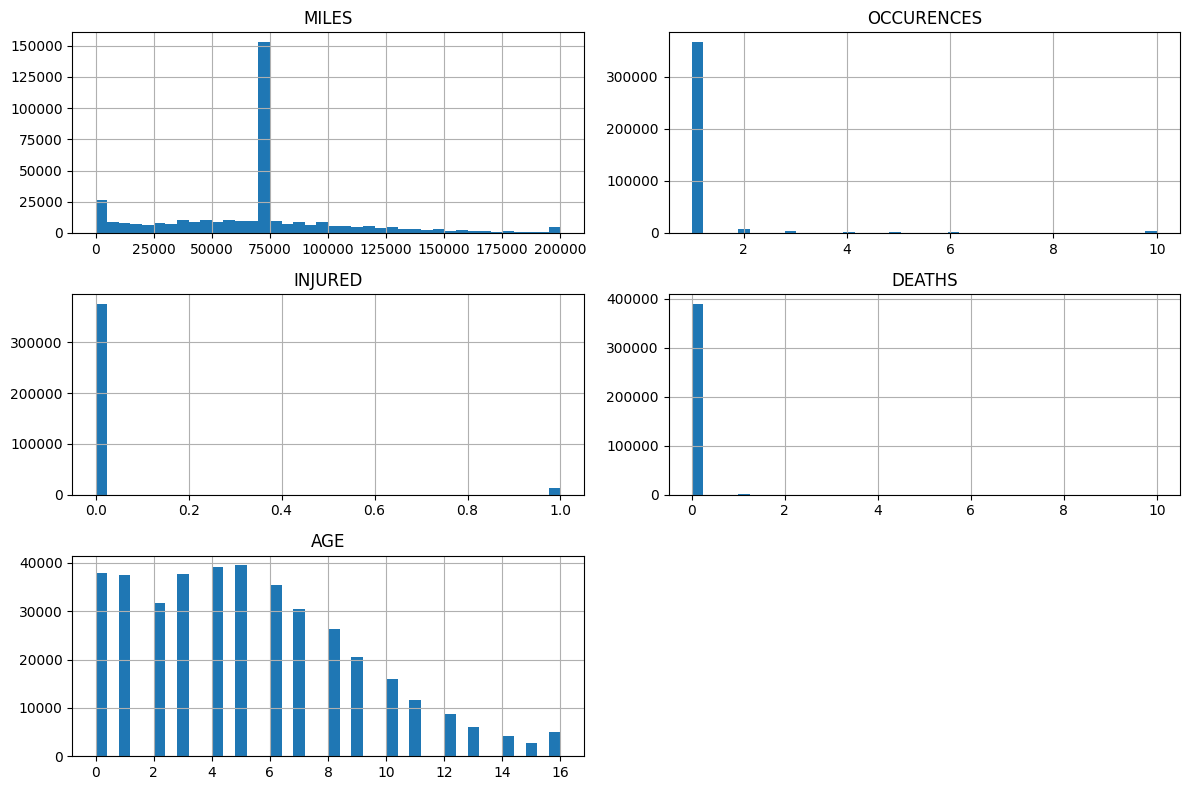

In [11]:
cols = ["MILES", "OCCURENCES", "INJURED", "DEATHS",  "AGE"]

df[cols].hist(bins=40, figsize=(12,8))
plt.tight_layout()
plt.show()

In [12]:
print("Crash rate:", df["CRASH"].mean())
print("Fire rate:", df["FIRE"].mean())
print("Injured rate:", (df["INJURED"] > 0).mean())
print("Death rate global:", round((df["DEATHS"] > 0).mean(), 4))

Crash rate: 0.05385803694718208
Fire rate: 0.017466779047038358
Injured rate: 0.03504884191002226
Death rate global: 0.0013


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEARTXT,390341.0,2009.674641,6.198030,2000.0,2004.0,2009.000000,2014.0,2026.0
CRASH,390341.0,0.053858,0.225738,0.0,0.0,0.000000,0.0,1.0
FAILDATE,390341.0,2014.892661,6.220633,2000.0,2010.0,2016.000000,2019.0,2026.0
FIRE,390341.0,0.017467,0.131003,0.0,0.0,0.000000,0.0,1.0
INJURED,390341.0,0.035049,0.183904,0.0,0.0,0.000000,0.0,1.0
DEATHS,390341.0,0.001614,0.055515,0.0,0.0,0.000000,0.0,10.0
MILES,390341.0,69311.792349,39240.228159,7.0,49500.0,71775.184051,75835.0,200185.0
OCCURENCES,390341.0,1.205397,1.093363,1.0,1.0,1.000000,1.0,10.0
AGE,390341.0,5.224583,3.782159,0.0,2.0,5.000000,8.0,16.0


In [14]:
vehicle_df = (
    df.groupby(["MAKETXT", "MODELTXT", "YEARTXT"], dropna=False)
    .agg(
        total_complaints=("MODELTXT", "size"),
        avg_age=("AGE", "mean"),
        median_miles=("MILES", "median"),
        avg_occurrences=("OCCURENCES", "mean"),
        crash_rate=("CRASH", "mean"),
        fire_rate=("FIRE", "mean"),
        injured_rate=("INJURED", lambda s: (s.fillna(0) > 0).mean()),
        total_injured=("INJURED", "sum"),
        total_deaths=("DEATHS", "sum"),
        top_issue=("COMPDESC", lambda s: s.astype(str).value_counts().index[0]),
    )
    .reset_index()
)

display(vehicle_df.head())
print(vehicle_df.shape)

,MAKETXT,MODELTXT,YEARTXT,total_complaints,avg_age,median_miles,avg_occurrences,crash_rate,fire_rate,injured_rate,total_injured,total_deaths,top_issue
0,CHEVROLET,ASTRO,2000.0,108,3.527778,71775.184051,2.361111,0.157407,0.000000,0.083333,9.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO..."
1,CHEVROLET,ASTRO,2001.0,58,4.293103,71775.184051,3.620690,0.051724,0.017241,0.000000,0.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO..."
2,CHEVROLET,ASTRO,2002.0,39,5.641026,71775.184051,2.153846,0.076923,0.076923,0.051282,2.0,4.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO..."
3,CHEVROLET,ASTRO,2003.0,53,4.018868,71775.184051,2.113208,0.056604,0.056604,0.056604,3.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO..."
4,CHEVROLET,ASTRO,2004.0,10,4.900000,69000.000000,1.300000,0.100000,0.000000,0.100000,1.0,0.0,"VISIBILITY:GLASS, SIDE/REAR"


(2276, 13)


In [15]:
vehicle_df["severity_score"] = (
    0.50 * vehicle_df["crash_rate"] +
    0.20 * vehicle_df["fire_rate"] +
    0.30 * vehicle_df["injured_rate"]
)

vehicle_df["log_total_complaints"] = np.log1p(vehicle_df["total_complaints"])
vehicle_df["log_median_miles"] = np.log1p(vehicle_df["median_miles"])
vehicle_df["log_avg_occurrences"] = np.log1p(vehicle_df["avg_occurrences"])

volume_score = (
    vehicle_df["log_total_complaints"] /
    vehicle_df["log_total_complaints"].max()
).fillna(0)

vehicle_df["risk_score"] = (
    0.85 * vehicle_df["severity_score"] +
    0.15 * volume_score
)

vehicle_df["risk_score"] = vehicle_df["risk_score"].clip(0, 1)

vehicle_df["risk_percentile"] = vehicle_df["risk_score"].rank(pct=True)

vehicle_df["severity_binary"] = (
    vehicle_df["crash_rate"] + vehicle_df["injured_rate"]
)

vehicle_df[["severity_score", "risk_score", "risk_percentile"]].describe()

,severity_score,risk_score,risk_percentile
count,2276.000000,2276.000000,2276.000000
mean,0.052866,0.121046,0.500220
std,0.069235,0.062247,0.288729
min,0.000000,0.012870,0.018893
25%,0.016634,0.092356,0.250275
50%,0.036364,0.123562,0.500220
75%,0.068343,0.147513,0.750110
max,0.800000,0.692870,0.998902


In [16]:
vehicle_df

,MAKETXT,MODELTXT,YEARTXT,total_complaints,avg_age,median_miles,avg_occurrences,crash_rate,fire_rate,injured_rate,total_injured,total_deaths,top_issue,severity_score,log_total_complaints,log_median_miles,log_avg_occurrences,risk_score,risk_percentile,severity_binary
0,CHEVROLET,ASTRO,2000.0,108,3.527778,71775.184051,2.361111,0.157407,0.000000,0.083333,9.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO...",0.103704,4.691348,11.181308,1.212272,0.175254,0.903339,0.240741
1,CHEVROLET,ASTRO,2001.0,58,4.293103,71775.184051,3.620690,0.051724,0.017241,0.000000,0.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO...",0.029310,4.077537,11.181308,1.530544,0.100623,0.300088,0.051724
2,CHEVROLET,ASTRO,2002.0,39,5.641026,71775.184051,2.153846,0.076923,0.076923,0.051282,2.0,4.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO...",0.069231,3.688879,11.181308,1.148623,0.127339,0.541740,0.128205
3,CHEVROLET,ASTRO,2003.0,53,4.018868,71775.184051,2.113208,0.056604,0.056604,0.056604,3.0,0.0,"SERVICE BRAKES, HYDRAULIC:ANTILOCK/TRACTION CO...",0.056604,3.988984,11.181308,1.135654,0.122178,0.485501,0.113208
4,CHEVROLET,ASTRO,2004.0,10,4.900000,69000.000000,1.300000,0.100000,0.000000,0.100000,1.0,0.0,"VISIBILITY:GLASS, SIDE/REAR",0.080000,2.397895,11.141876,0.832909,0.112523,0.391696,0.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2271,VOLKSWAGEN,TOUAREG,2013.0,21,3.761905,54000.000000,1.142857,0.047619,0.000000,0.000000,0.0,0.0,FUEL/PROPULSION SYSTEM,0.023810,3.091042,10.896758,0.762140,0.077631,0.174649,0.047619
2272,VOLKSWAGEN,TOUAREG,2014.0,12,2.916667,3023.000000,1.000000,0.000000,0.083333,0.000000,0.0,0.0,STEERING,0.016667,2.564949,8.014336,0.693147,0.061791,0.146090,0.000000
2273,VOLKSWAGEN,TOUAREG,2015.0,11,4.545455,47000.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.0,ENGINE,0.000000,2.484907,10.757924,0.693147,0.046138,0.118849,0.000000
2274,VOLKSWAGEN,TOUAREG,2016.0,29,3.862069,28000.000000,1.000000,0.000000,0.000000,0.034483,1.0,0.0,ENGINE,0.010345,3.401197,10.239996,0.693147,0.071944,0.163445,0.034483


In [17]:


vehicle_df["decision"] = vehicle_df["risk_score"].apply(decision_label)

display(vehicle_df["decision"].value_counts())

decision
Recomendado       1532
Con precaución     698
No recomendado      46
Name: count, dtype: int64

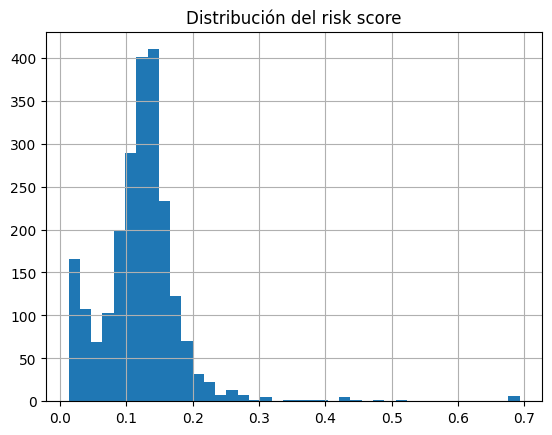

In [18]:
vehicle_df["risk_score"].hist(bins=40)
plt.title("Distribución del risk score")
plt.show()

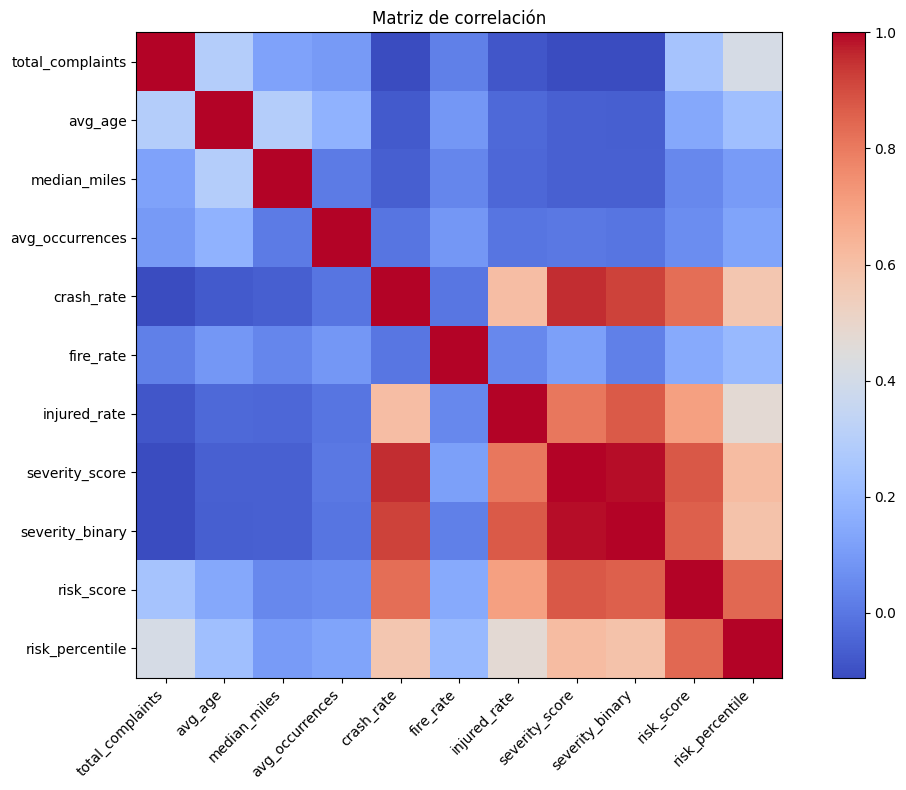

,total_complaints,avg_age,median_miles,avg_occurrences,crash_rate,fire_rate,injured_rate,severity_score,severity_binary,risk_score,risk_percentile
total_complaints,1.000,0.294,0.125,0.099,-0.112,0.024,-0.086,-0.111,-0.112,0.247,0.409
avg_age,0.294,1.000,0.294,0.176,-0.074,0.091,-0.036,-0.059,-0.064,0.143,0.230
median_miles,0.125,0.294,1.000,0.011,-0.062,0.042,-0.040,-0.056,-0.058,0.046,0.105
avg_occurrences,0.099,0.176,0.011,1.000,-0.007,0.088,-0.005,0.002,-0.007,0.060,0.128
crash_rate,-0.112,-0.074,-0.062,-0.007,1.000,-0.001,0.608,0.953,0.920,0.828,0.573
fire_rate,0.024,0.091,0.042,0.088,-0.001,1.000,0.047,0.116,0.023,0.151,0.204
injured_rate,-0.086,-0.036,-0.040,-0.005,0.608,0.047,1.000,0.806,0.870,0.704,0.472
severity_score,-0.111,-0.059,-0.056,0.002,0.953,0.116,0.806,1.000,0.989,0.875,0.610
severity_binary,-0.112,-0.064,-0.058,-0.007,0.920,0.023,0.870,0.989,1.000,0.861,0.588
risk_score,0.247,0.143,0.046,0.060,0.828,0.151,0.704,0.875,0.861,1.000,0.840


In [19]:
corr_cols = [
    "total_complaints",
    "avg_age",
    "median_miles",
    "avg_occurrences",
    "crash_rate",
    "fire_rate",
    "injured_rate",
    "severity_score",
    "severity_binary",
    "risk_score",
    "risk_percentile",
]

corr = vehicle_df[corr_cols].corr()

plt.figure(figsize=(11, 8))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

display(corr.round(3))

In [20]:
corr_risk = corr["risk_score"].sort_values(ascending=False)
display(corr_risk)

risk_score          1.000000
severity_score      0.874895
severity_binary     0.860785
risk_percentile     0.839984
crash_rate          0.827835
injured_rate        0.704236
total_complaints    0.247472
fire_rate           0.151240
avg_age             0.143226
avg_occurrences     0.060075
median_miles        0.045753
Name: risk_score, dtype: float64

In [21]:
cluster_features = [
    "risk_score",
    "severity_score",
    "severity_binary",
    "total_complaints",
    "avg_age",
    "median_miles",
    "avg_occurrences",
    "crash_rate",
    "fire_rate",
    "injured_rate",
]

X = vehicle_df[cluster_features].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape)

(2276, 10)


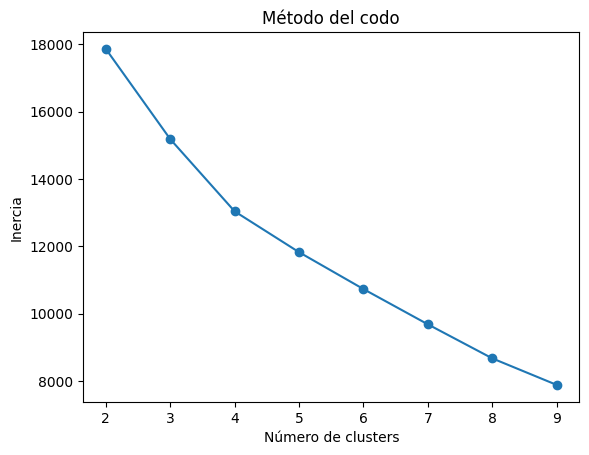

In [22]:
inertias = []
k_values = range(2, 10)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(list(k_values), inertias, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

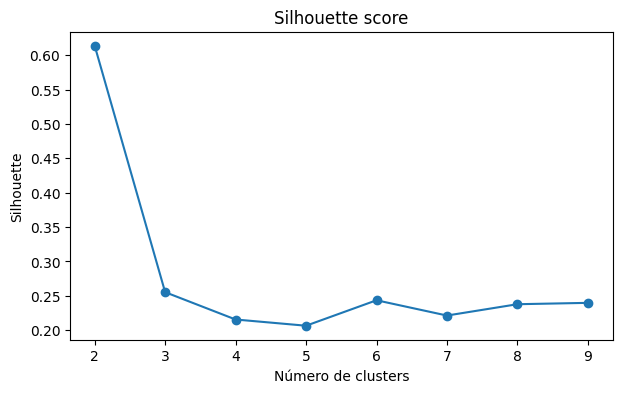

Mejor k: 2
Mejor silhouette: 0.614


In [23]:
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette score")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

best_k = list(k_values)[np.argmax(sil_scores)]
best_sil = max(sil_scores)

print("Mejor k:", best_k)
print("Mejor silhouette:", round(best_sil, 4))

In [24]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
vehicle_df["cluster"] = kmeans.fit_predict(X_scaled)

display(vehicle_df[["MAKETXT", "MODELTXT", "YEARTXT", "risk_score", "cluster"]].head())

,MAKETXT,MODELTXT,YEARTXT,risk_score,cluster
0,CHEVROLET,ASTRO,2000.0,0.175254,0
1,CHEVROLET,ASTRO,2001.0,0.100623,0
2,CHEVROLET,ASTRO,2002.0,0.127339,0
3,CHEVROLET,ASTRO,2003.0,0.122178,0
4,CHEVROLET,ASTRO,2004.0,0.112523,0


In [25]:
cluster_profile = (
    vehicle_df.groupby("cluster")
    .agg(
        size=("cluster", "size"),
        avg_risk=("risk_score", "mean"),
        avg_percentile=("risk_percentile", "mean"),
        avg_crash=("crash_rate", "mean"),
        avg_fire=("fire_rate", "mean"),
        avg_injured=("injured_rate", "mean"),
        avg_age=("avg_age", "mean"),
        avg_complaints=("total_complaints", "mean"),
        avg_miles=("median_miles", "mean"),
    )
    .sort_values("avg_risk", ascending=False)
)

display(cluster_profile.round(4))

,size,avg_risk,avg_percentile,avg_crash,avg_fire,avg_injured,avg_age,avg_complaints,avg_miles
cluster,,,,,,,,,
1,86,0.2948,0.9699,0.4141,0.0121,0.2961,2.8695,29.0349,60063.5695
0,2190,0.1142,0.4818,0.0583,0.0163,0.0361,4.2091,177.0977,67164.6712


In [26]:
cluster_profile = cluster_profile.copy()
cluster_profile["cluster_label"] = cluster_profile.apply(label_cluster, axis=1)

display(cluster_profile.round(4))

,size,avg_risk,avg_percentile,avg_crash,avg_fire,avg_injured,avg_age,avg_complaints,avg_miles,cluster_label
cluster,,,,,,,,,,
1,86,0.2948,0.9699,0.4141,0.0121,0.2961,2.8695,29.0349,60063.5695,Alto riesgo de seguridad
0,2190,0.1142,0.4818,0.0583,0.0163,0.0361,4.2091,177.0977,67164.6712,Base confiable


In [27]:
cluster_label_map = cluster_profile["cluster_label"].to_dict()
vehicle_df["cluster_label"] = vehicle_df["cluster"].map(cluster_label_map)

display(
    vehicle_df[
        ["MAKETXT", "MODELTXT", "YEARTXT", "risk_score", "decision", "cluster", "cluster_label"]
    ].head()
)

,MAKETXT,MODELTXT,YEARTXT,risk_score,decision,cluster,cluster_label
0,CHEVROLET,ASTRO,2000.0,0.175254,Con precaución,0,Base confiable
1,CHEVROLET,ASTRO,2001.0,0.100623,Recomendado,0,Base confiable
2,CHEVROLET,ASTRO,2002.0,0.127339,Recomendado,0,Base confiable
3,CHEVROLET,ASTRO,2003.0,0.122178,Recomendado,0,Base confiable
4,CHEVROLET,ASTRO,2004.0,0.112523,Recomendado,0,Base confiable


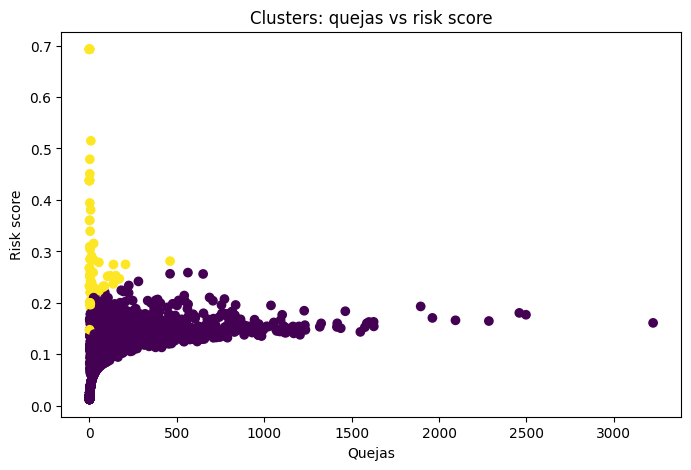

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(
    vehicle_df["total_complaints"],
    vehicle_df["risk_score"],
    c=vehicle_df["cluster"],
)
plt.xlabel("Quejas")
plt.ylabel("Risk score")
plt.title("Clusters: quejas vs risk score")
plt.show()

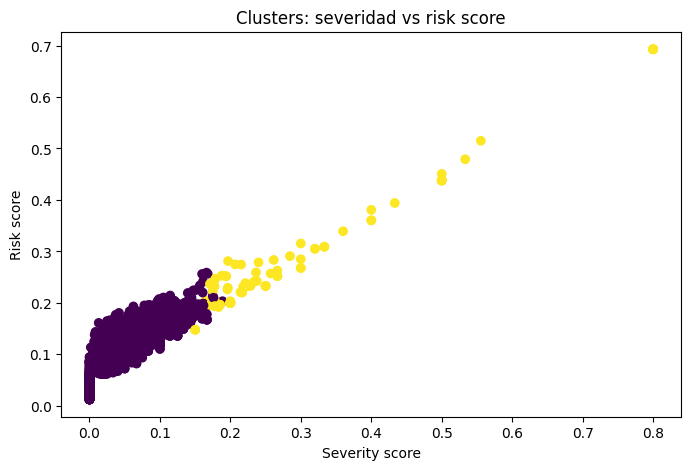

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(
    vehicle_df["severity_score"],
    vehicle_df["risk_score"],
    c=vehicle_df["cluster"],
)
plt.xlabel("Severity score")
plt.ylabel("Risk score")
plt.title("Clusters: severidad vs risk score")
plt.show()

In [30]:
top_risky = vehicle_df.sort_values("risk_score", ascending=False).head(20)

display(
    top_risky[
        [
            "MAKETXT",
            "MODELTXT",
            "YEARTXT",
            "risk_score",
            "risk_percentile",
            "decision",
            "crash_rate",
            "fire_rate",
            "injured_rate",
            "total_complaints",
            "cluster_label",
            "top_issue",
        ]
    ]
)

,MAKETXT,MODELTXT,YEARTXT,risk_score,risk_percentile,decision,crash_rate,fire_rate,injured_rate,total_complaints,cluster_label,top_issue
2230,VOLKSWAGEN,POLO 1.6 COMFORTLINE,2011.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,AIR BAGS
1927,TOYOTA,PRIUS C,2017.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,VEHICLE SPEED CONTROL
288,CHEVROLET,SPARK,2022.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,AIR BAGS
1268,MAZDA,CX-3,2020.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,AIR BAGS
1422,NISSAN,370Z,2018.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,SERVICE BRAKES
1419,NISSAN,370Z,2015.0,0.692870,0.998902,No recomendado,1.000000,0.00,1.000000,1,Alto riesgo de seguridad,AIR BAGS
2081,TOYOTA,YARIS,2015.0,0.514975,0.997364,No recomendado,0.777778,0.00,0.555556,9,Alto riesgo de seguridad,AIR BAGS
1392,MAZDA,MX-5,2009.0,0.479073,0.996924,No recomendado,0.666667,0.00,0.666667,3,Alto riesgo de seguridad,AIR BAGS
1788,TOYOTA,COROLLA,2026.0,0.450740,0.996485,No recomendado,1.000000,0.00,0.000000,3,Alto riesgo de seguridad,FORWARD COLLISION AVOIDANCE: AUTOMATIC EMERGEN...
1193,KIA,SORENTO,2010.0,0.437870,0.995167,No recomendado,1.000000,0.00,0.000000,1,Alto riesgo de seguridad,AIR BAGS


In [31]:
top_safe = vehicle_df.sort_values("risk_score", ascending=True).head(20)

display(
    top_safe[
        [
            "MAKETXT",
            "MODELTXT",
            "YEARTXT",
            "risk_score",
            "risk_percentile",
            "decision",
            "crash_rate",
            "fire_rate",
            "injured_rate",
            "total_complaints",
            "cluster_label",
            "top_issue",
        ]
    ]
)

,MAKETXT,MODELTXT,YEARTXT,risk_score,risk_percentile,decision,crash_rate,fire_rate,injured_rate,total_complaints,cluster_label,top_issue
65,CHEVROLET,CAPTIVA,2011.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,POWER TRAIN
1983,TOYOTA,SEQUOIA,2021.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,SUSPENSION
587,FORD,FORD GT,2005.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,AIR BAGS
1986,TOYOTA,SEQUOIA HYBRID,2026.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,SERVICE BRAKES
2017,TOYOTA,SUPRA,2024.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,PARKING BRAKE:ELECTRICAL
547,FORD,FIESTA,2002.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,POWER TRAIN
1276,MAZDA,CX-5,2012.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,VEHICLE SPEED CONTROL
127,CHEVROLET,CORVETTE ZR1,2009.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,POWER TRAIN:CLUTCH ASSEMBLY
1293,MAZDA,CX-50,2026.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,FORWARD COLLISION AVOIDANCE: AUTOMATIC EMERGEN...
1300,MAZDA,CX-7,2013.0,0.01287,0.018893,Recomendado,0.0,0.0,0.0,1,Base confiable,VEHICLE SPEED CONTROL


In [32]:
print("Resumen final del análisis")
print("- Número de vehículos agregados:", len(vehicle_df))
print("- Mejor número de clusters:", best_k)
print("- Mejor silhouette:", round(best_sil, 4))
print("- Distribución de decisión:")
display(vehicle_df["decision"].value_counts(normalize=True).round(4))

Resumen final del análisis
- Número de vehículos agregados: 2276
- Mejor número de clusters: 2
- Mejor silhouette: 0.614
- Distribución de decisión:


decision
Recomendado       0.6731
Con precaución    0.3067
No recomendado    0.0202
Name: proportion, dtype: float64

In [33]:
display(cluster_profile.round(4))

,size,avg_risk,avg_percentile,avg_crash,avg_fire,avg_injured,avg_age,avg_complaints,avg_miles,cluster_label
cluster,,,,,,,,,,
1,86,0.2948,0.9699,0.4141,0.0121,0.2961,2.8695,29.0349,60063.5695,Alto riesgo de seguridad
0,2190,0.1142,0.4818,0.0583,0.0163,0.0361,4.2091,177.0977,67164.6712,Base confiable


In [34]:
top_issues_by_make = (
    df.groupby(["MAKETXT", "COMPDESC"])
    .size()
    .reset_index(name="count")
    .sort_values(["MAKETXT", "count"], ascending=[True, False])
)

display(top_issues_by_make.head(20))

,MAKETXT,COMPDESC,count
28,CHEVROLET,ELECTRICAL SYSTEM,9132
329,CHEVROLET,UNKNOWN OR OTHER,5077
0,CHEVROLET,AIR BAGS,4947
249,CHEVROLET,STEERING,4409
211,CHEVROLET,SERVICE BRAKES,4031
53,CHEVROLET,ENGINE,3914
50,CHEVROLET,ELECTRONIC STABILITY CONTROL (ESC),3204
144,CHEVROLET,FUEL/PROPULSION SYSTEM,3148
165,CHEVROLET,POWER TRAIN,3116
121,CHEVROLET,"FUEL SYSTEM, GASOLINE",1735


In [35]:
brand_avg = (
    vehicle_df.groupby("MAKETXT")["risk_score"]
    .mean()
    .reset_index(name="brand_avg_risk")
)

vehicle_df = vehicle_df.merge(brand_avg, on="MAKETXT", how="left")
vehicle_df["vs_brand_avg"] = vehicle_df["risk_score"] - vehicle_df["brand_avg_risk"]

display(
    vehicle_df[
        ["MAKETXT", "MODELTXT", "YEARTXT", "risk_score", "brand_avg_risk", "vs_brand_avg"]
    ].head()
)

,MAKETXT,MODELTXT,YEARTXT,risk_score,brand_avg_risk,vs_brand_avg
0,CHEVROLET,ASTRO,2000.0,0.175254,0.119436,0.055818
1,CHEVROLET,ASTRO,2001.0,0.100623,0.119436,-0.018814
2,CHEVROLET,ASTRO,2002.0,0.127339,0.119436,0.007902
3,CHEVROLET,ASTRO,2003.0,0.122178,0.119436,0.002742
4,CHEVROLET,ASTRO,2004.0,0.112523,0.119436,-0.006914


*****

In [36]:
# 1. Identificar el cluster de bajo riesgo
cluster_risk_map = (
    vehicle_df.groupby("cluster")["risk_score"]
    .mean()
    .sort_values()
)

low_risk_cluster = cluster_risk_map.index[0]   # menor risk_score promedio
high_risk_cluster = cluster_risk_map.index[-1]

print("Cluster bajo riesgo:", low_risk_cluster)
print("Cluster alto riesgo:", high_risk_cluster)


# 2. Filtrar solo el cluster de bajo riesgo
low_risk_df = vehicle_df[vehicle_df["cluster"] == low_risk_cluster].copy()


# 3. Selección de features para subcluster
subcluster_features = [
    "severity_score",
    "total_complaints",
    "avg_age",
    "median_miles",
    "avg_occurrences",
    "crash_rate",
    "fire_rate",
    "injured_rate",
]

X_sub = low_risk_df[subcluster_features].copy()
X_sub = X_sub.replace([np.inf, -np.inf], np.nan)
X_sub = X_sub.fillna(X_sub.median(numeric_only=True))


# 4. Escalado
X_sub_scaled = scaler.fit_transform(X_sub)


# 5. Elegir número de subclusters (puedes cambiar a 3 o 4)
k_sub = 3

kmeans_sub = KMeans(n_clusters=k_sub, random_state=42, n_init=20)
low_risk_df["subcluster"] = kmeans_sub.fit_predict(X_sub_scaled)


# 6. Mapear subclusters al dataframe original
vehicle_df["subcluster"] = -1 
vehicle_df.loc[low_risk_df.index, "subcluster"] = low_risk_df["subcluster"]


# 7. Perfil de subclusters
subcluster_profile = (
    low_risk_df.groupby("subcluster")
    .agg(
        size=("subcluster", "size"),
        avg_risk=("risk_score", "mean"),
        avg_crash=("crash_rate", "mean"),
        avg_fire=("fire_rate", "mean"),
        avg_injured=("injured_rate", "mean"),
        avg_age=("avg_age", "mean"),
        avg_complaints=("total_complaints", "mean"),
        avg_miles=("median_miles", "mean"),
    )
    .sort_values("avg_risk", ascending=False)
)

display(subcluster_profile.round(4))

Cluster bajo riesgo: 0
Cluster alto riesgo: 1


,size,avg_risk,avg_crash,avg_fire,avg_injured,avg_age,avg_complaints,avg_miles
subcluster,,,,,,,,
1,519,0.1551,0.1333,0.0247,0.0839,3.9247,91.9884,66445.3203
2,742,0.1273,0.0437,0.0201,0.0288,6.1282,370.5499,73024.3418
0,929,0.0809,0.0279,0.0086,0.0152,2.8351,70.1335,62886.3801


In [37]:
subcluster_profile = subcluster_profile.copy()
subcluster_profile["subcluster_label"] = subcluster_profile.apply(label_subcluster, axis=1)

display(subcluster_profile.round(4))

,size,avg_risk,avg_crash,avg_fire,avg_injured,avg_age,avg_complaints,avg_miles,subcluster_label
subcluster,,,,,,,,,
1,519,0.1551,0.1333,0.0247,0.0839,3.9247,91.9884,66445.3203,Base confiable
2,742,0.1273,0.0437,0.0201,0.0288,6.1282,370.5499,73024.3418,Alto volumen de quejas (desgaste)
0,929,0.0809,0.0279,0.0086,0.0152,2.8351,70.1335,62886.3801,Base confiable


In [38]:
subcluster_label_map = subcluster_profile["subcluster_label"].to_dict()

vehicle_df["subcluster_label"] = vehicle_df["subcluster"].map(subcluster_label_map)

# para el cluster de alto riesgo (que no tiene subcluster)
vehicle_df.loc[vehicle_df["cluster"] == high_risk_cluster, "subcluster_label"] = "Alto riesgo crítico"

display(
    vehicle_df[
        ["MAKETXT", "MODELTXT", "YEARTXT", "risk_score", "cluster", "subcluster", "subcluster_label"]
    ].head(10)
)

,MAKETXT,MODELTXT,YEARTXT,risk_score,cluster,subcluster,subcluster_label
0,CHEVROLET,ASTRO,2000.0,0.175254,0,1,Base confiable
1,CHEVROLET,ASTRO,2001.0,0.100623,0,2,Alto volumen de quejas (desgaste)
2,CHEVROLET,ASTRO,2002.0,0.127339,0,2,Alto volumen de quejas (desgaste)
3,CHEVROLET,ASTRO,2003.0,0.122178,0,2,Alto volumen de quejas (desgaste)
4,CHEVROLET,ASTRO,2004.0,0.112523,0,1,Base confiable
5,CHEVROLET,ASTRO,2005.0,0.106964,0,1,Base confiable
6,CHEVROLET,AVALANCHE,2000.0,0.020398,0,0,Base confiable
7,CHEVROLET,AVALANCHE,2001.0,0.020398,0,2,Alto volumen de quejas (desgaste)
8,CHEVROLET,AVALANCHE,2002.0,0.152485,0,2,Alto volumen de quejas (desgaste)
9,CHEVROLET,AVALANCHE,2003.0,0.125100,0,2,Alto volumen de quejas (desgaste)


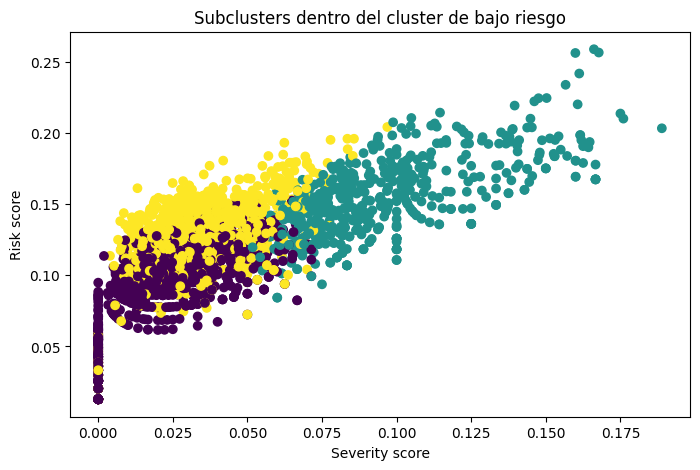

: 

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(
    low_risk_df["severity_score"],
    low_risk_df["risk_score"],
    c=low_risk_df["subcluster"]
)

plt.xlabel("Severity score")
plt.ylabel("Risk score")
plt.title("Subclusters dentro del cluster de bajo riesgo")
plt.show()